Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Load raw training and validation files

In [ ]:
import pandas as pd
from sklearn.utils import class_weight
import numpy as np

train_dataset = "/content/drive/Shareddrives/171Project/dataset/raw_train.csv"    #raw train files
train_df = pd.read_csv(train_dataset)

val_dataset = "/content/drive/Shareddrives/171Project/dataset/raw_val.csv"    #raw validation files
val_df = pd.read_csv(val_dataset)

Map the classes to either normal or abnormal

In [ ]:
mapping = {
    'normal': 0,
    'anxiety': 1,
    'depression': 1,
    'suicidal': 1,
    'stress': 1,
    'bipolar': 1,
    'personality disorder': 1
}

train_df['abnormality'] = train_df['status'].map(mapping)
val_df['abnormality'] = val_df['status'].map(mapping)
print(train_df.head())

                                           statement    status  abnormality
0  to put some context i have been though some th...  suicidal            1
1  michaelgrainger scyranth gigglessssssss yall a...    normal            0
2  so right now they are planning to meet at the ...  suicidal            1
3                              being broke is no fun    normal            0
4                  you dont need to worry about that    normal            0


In [ ]:
X_train = np.array(train_df["statement"].astype(str), dtype=object)
y_train = train_df["abnormality"]
print(train_df.head(10))  #verify train set

X_val = np.array(val_df["statement"].astype(str), dtype=object)
y_val = val_df["abnormality"]


                                           statement    status  abnormality
0  to put some context i have been though some th...  suicidal            1
1  michaelgrainger scyranth gigglessssssss yall a...    normal            0
2  so right now they are planning to meet at the ...  suicidal            1
3                              being broke is no fun    normal            0
4                  you dont need to worry about that    normal            0
5            insomnia how do you guys fight insomnia    stress            1
6               i am so tired someone comment please  suicidal            1
7  sadly nothings improvingmy dui case has finall...  suicidal            1
8  time to fly orddcaordclt 16hrs cltordiadmco 13...    normal            0
9  sudden severe head and neck painshould i worry...   anxiety            1


Abnormal classes have far more samples than normal classes, so we add weights to balance it out for the neural network.

In [ ]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_dict = {i: weights[i] for i in range(len(weights))}    #should look like {0: __, 1: __}

print(f"Class Weights: {weights_dict}")

Class Weights: {0: np.float64(1.6117132867132866), 1: np.float64(0.7248781254914295)}


Create the Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# standardizes text
max_features = 10000 #vocab size
sequence_length = 100

vectorize_layer = layers.TextVectorization(
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)

vectorize_layer.adapt(train_df['statement'])

#build model
model = tf.keras.Sequential([
    layers.Input(shape=(1,), dtype=tf.string), #accept raw strings
    vectorize_layer,
    layers.Embedding(max_features, 16),    #vectors are 16 dimensions
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.5),     #for regularization
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')     # sigmoid function outputs from [0,1]
])

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ])

Training

In [ ]:
history = model.fit(
    x=X_train,
    y=y_train,
    epochs=10, #default=10
    class_weight=weights_dict,
    batch_size=32,
    validation_data=(X_val, y_val) # validation is passed here
)

Epoch 1/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6586 - loss: 0.5914 - precision: 0.9767 - recall: 0.5144 - val_accuracy: 0.7901 - val_loss: 0.4713 - val_precision: 0.9560 - val_recall: 0.7292
Epoch 2/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8189 - loss: 0.3998 - precision: 0.9601 - recall: 0.7693 - val_accuracy: 0.8431 - val_loss: 0.3542 - val_precision: 0.9521 - val_recall: 0.8134
Epoch 3/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8491 - loss: 0.3510 - precision: 0.9520 - recall: 0.8229 - val_accuracy: 0.8559 - val_loss: 0.3313 - val_precision: 0.9514 - val_recall: 0.8336
Epoch 4/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8641 - loss: 0.3323 - precision: 0.9551 - recall: 0.8427 - val_accuracy: 0.8621 - val_loss: 0.3212 - val_precision: 0.9517 - val_recall: 0.8428
Epoch 5/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8712 - loss: 0.3217 - precision: 0.9557 - recall: 0.8532 - val_accuracy: 0.8671 - va

Plot Results

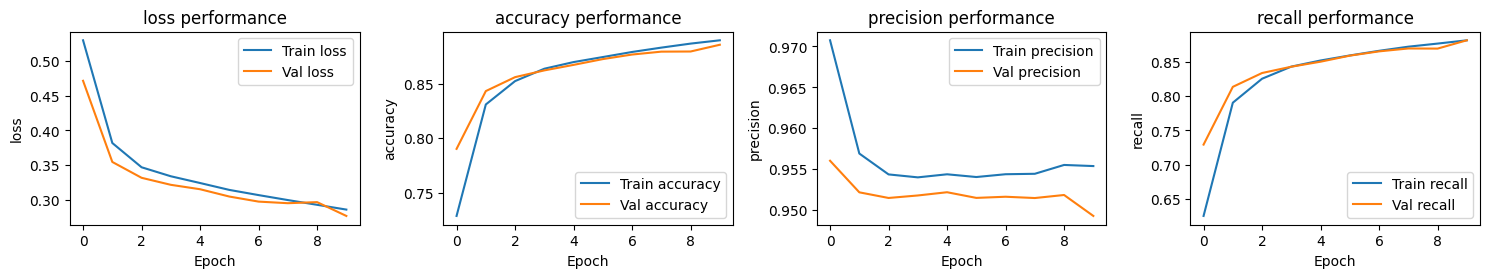

In [ ]:
import matplotlib.pyplot as plt

def plot_performance_metrics(history):
    metrics = ['loss', 'accuracy', 'precision', 'recall']
    plt.figure(figsize=(15, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(4, 4, i+1)
        plt.plot(history.history[metric], label='Train ' + metric)
        plt.plot(history.history['val_' + metric], label='Val ' + metric)
        plt.title(f'{metric} performance')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_performance_metrics(history)

#TF-IDF Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

tfidf = TfidfVectorizer(max_features=1000) # top 1000 most important words

X_train_tfidf = tfidf.fit_transform(train_df['statement'])
X_val_tfidf = tfidf.transform(val_df['statement'])

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred = lr_model.predict(X_val_tfidf)
print(classification_report(y_val, y_pred))



              precision    recall  f1-score   support

           0       0.83      0.95      0.89      2451
           1       0.98      0.91      0.94      5451

    accuracy                           0.92      7902
   macro avg       0.90      0.93      0.91      7902
weighted avg       0.93      0.92      0.92      7902

